<img src="imgs/unifor_logo.png" width="400">
<br>
<b>
<font size="6" face="arial" color="blue">
    Graduação em Ciência da Computação
</font>
</b>
<br
<b>
<font size="4" face="arial">
    Disciplina: Métodos Quantitativos para Computação
</font>
</b>

**Orientador: Prof. Me. Ricardo Carubbi** <br>
*Docente da Graduação e Pós-Graduação em Ciência de Dados e Inteligência Artificial*<br>
*Laboratório de Ciência de Dados e Inteligência Artificial*<br>
*Universidade de Fortaleza*<br>

<p dir="ltr" style="text-align: left;">
    <strong>Links:</strong>
    <a href="https://www2.unifor.br/controle_pesquisa/pesquisarprofessor.do?actionParameter=prepareUpdate&amp;p_tp_ambiente=2&amp;p_tp_chamada=1&amp;p_tp_apresentacao=1&amp;cdPesquisador=767686193" target="_blank">Unifor</a|
    <a href="http://lattes.cnpq.br/5738786447903616" target="_blank">Lattes</a|
    <a href="https://unifor.br/web/pesquisa-inovacao/ncdia" target="_blank">NCDIA</a|
    <a href="https://github.com/carubbi/" target="_blank">Github</a>
</p>

# **Regressão Linear Simples**

A **regressão linear simples (RLS)** é um modelo estatístico utilizado para descrever e quantificar a associação linear entre uma **variável resposta** quantitativa e uma única **variável preditora** quantitativa. Em sua forma clássica, o modelo admite que a média condicional da variável resposta é uma função linear da variável preditora, acrescida de um termo aleatório que representa a variabilidade não explicada pelo componente sistemático do modelo.

Neste notebook, a regressão linear simples será tratada como um procedimento inferencial e diagnóstico, não apenas como uma técnica de ajuste gráfico. A ênfase recai sobre a estimação por **mínimos quadrados (MQ; Ordinary Least Squares, OLS)**, a interpretação dos parâmetros, a decomposição da variabilidade, a análise dos resíduos e a identificação de observações com alavancagem ou influência excessiva.


## **Objetivos de Aprendizagem**

Ao final deste notebook, espera-se que o estudante seja capaz de:

- formular o modelo de regressão linear simples em notação estatística;
- estimar analiticamente o intercepto e o coeficiente angular por mínimos quadrados;
- interpretar coeficientes estimados, valores ajustados, resíduos e intervalos de incerteza;
- distinguir ajuste visual, capacidade explicativa e validade diagnóstica do modelo;
- utilizar gráficos diagnósticos para avaliar resíduos, normalidade aproximada, homocedasticidade e alavancagem.


## **Vídeos Complementares: Regressão Linear e Mínimos Quadrados**

Os vídeos abaixo são materiais complementares do canal **StatQuest with Josh Starmer**. A sequência foi organizada para acompanhar a progressão didática do notebook: primeiro a ideia de ajustar uma reta aos dados, depois a regressão linear como modelo estatístico e, por fim, uma síntese conceitual da interpretação do modelo.


### Vídeo 1: The Main Ideas of Fitting a Line to Data

Assista ao vídeo explicativo sobre **ajuste de uma reta por mínimos quadrados** neste [link](https://youtu.be/PaFPbb66DxQ?si=Ue6V_yZbtJGiba0J):

<img src="imgs/statquest_rls_least_squares.jpg" width="400">


### Vídeo 2: Linear Regression, Clearly Explained

Assista ao vídeo explicativo sobre **regressão linear** neste [link](https://youtu.be/7ArmBVF2dCs?si=Nn0MEB1J9_w-0tmc):

<img src="imgs/statquest_rls_linear_regression.jpg" width="400">


### Vídeo 3: The Essence of Linear Regression

Assista ao vídeo explicativo sobre a **essência da regressão linear** neste [link](https://youtu.be/aFDOzpTeg0s?si=Z_Ay9y-_QMKKmmjz):

<img src="imgs/statquest_rls_details.jpg" width="400">


## **Formulação Estatística do Modelo**

Sejam $(x_i, y_i)$, para $i = 1, \ldots, n$, observações pareadas de uma variável preditora $X$ e de uma variável resposta $Y$. O modelo de regressão linear simples é definido por:

$$Y_i = \beta_0 + \beta_1X_i + \varepsilon_i,$$

em que:

- $\beta_0$ é o **intercepto**, isto é, o valor esperado de $Y$ quando $X = 0$, quando essa extrapolação é substantivamente admissível;
- $\beta_1$ é o **coeficiente angular**, isto é, a variação esperada em $Y$ associada ao aumento unitário em $X$;
- $\varepsilon_i$ é o termo de erro aleatório, responsável pela parcela de $Y_i$ não descrita pela relação linear média.

A formulação inferencial usual assume que $E(\varepsilon_i)=0$, $Var(\varepsilon_i)=\sigma^2$, independência entre os erros e, para inferência paramétrica exata em pequenas amostras, normalidade dos erros. Essas hipóteses não devem ser tratadas como formalidades: elas orientam a validade dos testes, intervalos de confiança e intervalos de predição.


## **Importação das Bibliotecas**

Serão utilizadas bibliotecas estatísticas já disponíveis no ambiente virtual do projeto. A estimação do modelo será feita com `statsmodels`, pois a ênfase deste notebook é inferencial: coeficientes, erros padrão, estatísticas de teste, intervalos e diagnósticos.


In [1]:
# Configuração do ambiente analítico e gráfico.
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from scipy import stats

# Oculta avisos futuros que não alteram os resultados da aula.
warnings.filterwarnings("ignore", category=FutureWarning)

# Define um padrão visual consistente usando apenas Matplotlib.
plt.style.use("default")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
plt.rcParams["grid.linestyle"] = "--"
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False


## **Conjunto de Dados**

O conjunto de dados `students` é utilizado pela SOGA-Py e contém informações antropométricas e acadêmicas de estudantes. Para este notebook, serão consideradas as variáveis `height` e `weight`, de modo que a massa corporal seja modelada como variável resposta e a altura como variável preditora.

Essa escolha tem finalidade didática: não implica uma afirmação causal. Em regressão linear simples, a interpretação causal exige pressupostos adicionais que não decorrem apenas do ajuste estatístico.


In [2]:
# Carrega a base offline usada no exemplo de regressão linear simples.
file_path = "../../dataset/students_rls.csv"
students = pd.read_csv(file_path)

# Mantém apenas as variáveis necessárias e remove observações incompletas.
students_rls = students.loc[:, ["height", "weight"]].dropna().copy()
students_rls.head()


,height,weight
0,160,64.8
1,172,73.0
2,168,70.6
3,183,79.7
4,175,71.4


In [3]:
# Resume posição, dispersão e amplitude das variáveis do modelo.
students_rls.describe().round(2)


,height,weight
count,8239.00,8239.00
mean,171.38,73.00
std,11.08,8.64
min,135.00,51.40
25%,163.00,66.50
50%,171.00,71.80
75%,180.00,78.50
max,206.00,116.00


Para manter o exemplo suficientemente pequeno para inspeção manual, será extraída uma amostra aleatória de 24 estudantes. A semente aleatória é fixada para garantir reprodutibilidade.


In [4]:
# Seleciona uma amostra reprodutível para facilitar inspeção manual dos cálculos.
n = 30
sample = students_rls.sample(n=n, random_state=14).sort_values("height").reset_index(drop=True)
sample.head()


,height,weight
0,154,61.6
1,156,66.9
2,160,67.2
3,160,65.9
4,160,63.6


## **Exploração Gráfica Inicial**

O diagrama de dispersão permite examinar a direção, a intensidade aparente e a forma da associação entre altura e massa corporal. A visualização é exploratória; a estimação formal será realizada nas seções seguintes.


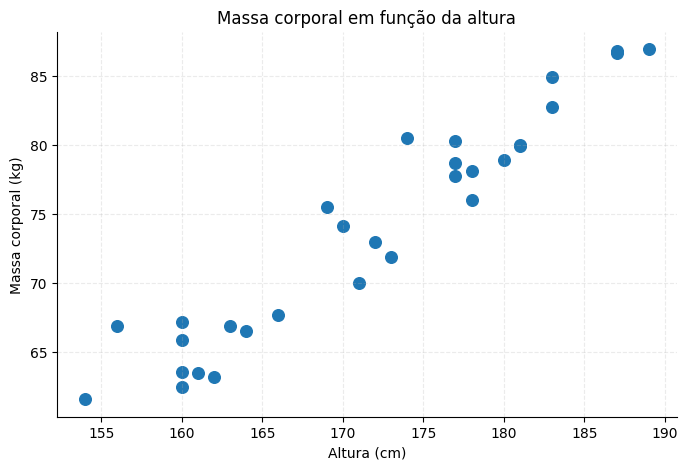

In [5]:
# Visualiza a associação empírica entre variável preditora e variável resposta.
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(sample["height"], sample["weight"], s=70)
ax.set_title("Massa corporal em função da altura")
ax.set_xlabel("Altura (cm)")
ax.set_ylabel("Massa corporal (kg)")
plt.show()


**Figura 1 - Diagrama de dispersão entre altura e massa corporal.** A figura apresenta a distribuição conjunta das observações amostrais, permitindo avaliar visualmente direção, forma e intensidade aproximada da associação entre a variável preditora e a variável resposta. Observa-se tendência positiva entre altura e massa corporal, o que justifica a estimação inicial de um modelo de regressão linear simples. Fonte: SOGA-Py, 2026.


## **Estimação por Mínimos Quadrados**

Na regressão linear simples, o objetivo é estimar uma reta que represente a **tendência média condicional** da variável resposta em função da variável preditora. Essa reta não deve ser entendida como uma descrição perfeita de todos os pontos observados, mas como uma síntese linear da relação média entre as variáveis.

O **método dos mínimos quadrados (MQ)** é o procedimento utilizado para estimar o intercepto e o coeficiente angular da reta de regressão. A ideia central é escolher os valores de $\hat{\beta}_0$ e $\hat{\beta}_1$ que tornam os resíduos, em conjunto, os menores possíveis segundo um critério específico.

Em termos operacionais, o método minimiza a **soma dos quadrados dos resíduos**, isto é, a soma das diferenças verticais ao quadrado entre os valores observados $y_i$ e os valores ajustados $\hat{y}_i$:

$$S(\beta_0,\beta_1)=\sum_{i=1}^{n}\left(y_i - \beta_0 - \beta_1x_i\right)^2.$$

Esse critério é útil porque fornece uma solução única, interpretável e computacionalmente simples para o ajuste da reta. Além disso, sob as hipóteses clássicas do modelo linear, os estimadores obtidos por MQ possuem propriedades estatísticas importantes, como não viesamento e eficiência dentro da classe dos estimadores lineares não viesados.

Para o modelo com uma única variável preditora, as soluções analíticas são:

$$\hat{\beta}_1 = \frac{\sum_{i=1}^{n}(x_i-\bar{x})(y_i-\bar{y})}{\sum_{i=1}^{n}(x_i-\bar{x})^2},$$

$$\hat{\beta}_0 = \bar{y} - \hat{\beta}_1\bar{x}.$$


In [6]:
# Converte as variáveis em vetores numéricos para aplicar as fórmulas de MQ.
x = sample["height"].to_numpy()
y = sample["weight"].to_numpy()

# Calcula as médias amostrais usadas nas estimativas analíticas.
x_bar = np.mean(x)
y_bar = np.mean(y)

# Estima o coeficiente angular e o intercepto por mínimos quadrados.
beta1_hat = np.sum((x - x_bar) * (y - y_bar)) / np.sum((x - x_bar) ** 2)
beta0_hat = y_bar - beta1_hat * x_bar

pd.Series(
    {
        "intercepto_estimado": beta0_hat,
        "coeficiente_angular_estimado": beta1_hat,
        "media_altura": x_bar,
        "media_massa": y_bar,
    }
).round(4)


intercepto_estimado             -57.7419
coeficiente_angular_estimado      0.7666
media_altura                    171.7667
media_massa                      73.9333
dtype: float64

A equação ajustada pode ser escrita como:

$$\hat{Y}_i = \hat{\beta}_0 + \hat{\beta}_1X_i.$$

O coeficiente angular deve ser interpretado em unidades da variável resposta por unidade da variável preditora. Neste exemplo, ele representa a variação média estimada na massa corporal, em quilogramas, associada ao aumento de 1 cm na altura.


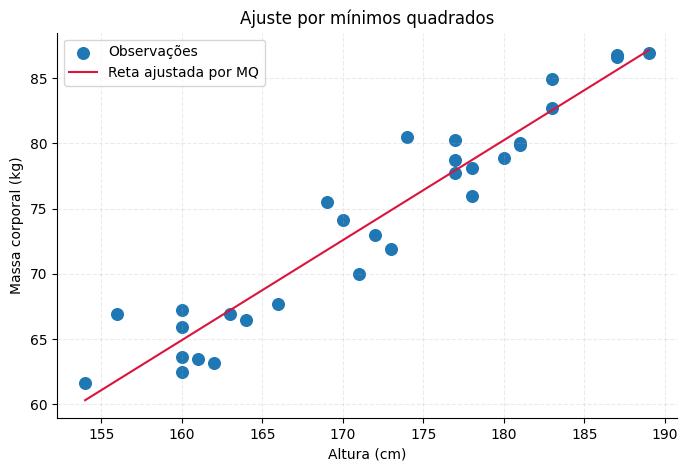

In [7]:
# Calcula valores ajustados e resíduos na escala original da variável resposta.
sample["fitted_manual"] = beta0_hat + beta1_hat * sample["height"]
sample["residual_manual"] = sample["weight"] - sample["fitted_manual"]

# Sobrepõe a reta estimada ao diagrama de dispersão.
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(sample["height"], sample["weight"], s=70, label="Observações")
ax.plot(sample["height"], sample["fitted_manual"], color="crimson", label="Reta ajustada por MQ")
ax.set_title("Ajuste por mínimos quadrados")
ax.set_xlabel("Altura (cm)")
ax.set_ylabel("Massa corporal (kg)")
ax.legend()
plt.show()


**Figura 2 - Reta de regressão estimada pelo método dos mínimos quadrados.** A figura sobrepõe a reta ajustada ao diagrama de dispersão, evidenciando a relação linear média estimada entre altura e massa corporal. A inclinação positiva indica que maiores valores de altura estão associados, em média, a maiores valores de massa corporal na amostra analisada. Fonte: SOGA-Py, 2026.


## **Visualização dos Resíduos no Gráfico de Dispersão**

Os resíduos podem ser representados graficamente como segmentos verticais entre cada valor observado $y_i$ e seu respectivo valor ajustado $\hat{y}_i$. Essa representação enfatiza que, no modelo estimado por mínimos quadrados, o erro considerado na função objetivo é vertical em relação ao eixo da variável resposta:

$$e_i = y_i - \hat{y}_i.$$

Esses segmentos não representam a distância ortogonal de cada ponto até a reta; representam a discrepância na escala da variável resposta.


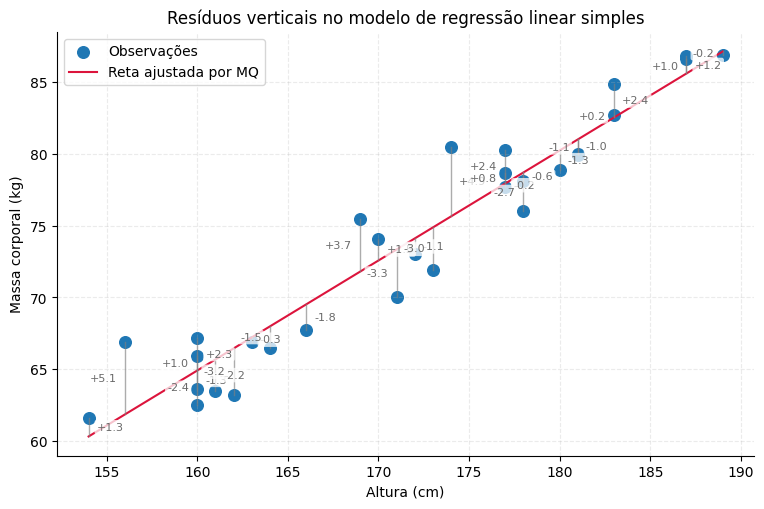

In [8]:
# Reordena os dados apenas para melhorar a leitura visual da reta e dos resíduos.
fig, ax = plt.subplots(figsize=(9, 5.5))
plot_data = sample.sort_values("height").reset_index(drop=True)

ax.scatter(plot_data["height"], plot_data["weight"], s=70, label="Observações")
ax.plot(plot_data["height"], plot_data["fitted_manual"], color="crimson", label="Reta ajustada por MQ")

# Cada segmento vertical representa e_i = y_i - y_hat_i.
for i, row in plot_data.iterrows():
    residual = row["residual_manual"]
    y_mid = (row["weight"] + row["fitted_manual"]) / 2
    x_offset = 0.45 if i % 2 == 0 else -0.45
    horizontal_alignment = "left" if x_offset > 0 else "right"

    ax.plot(
        [row["height"], row["height"]],
        [row["weight"], row["fitted_manual"]],
        color="gray",
        alpha=0.65,
        linewidth=1,
    )
    ax.text(
        row["height"] + x_offset,
        y_mid,
        f"{residual:+.1f}",
        fontsize=8,
        color="dimgray",
        ha=horizontal_alignment,
        va="center",
        bbox={"boxstyle": "round,pad=0.2", "facecolor": "white", "edgecolor": "none", "alpha": 0.75},
    )

ax.set_title("Resíduos verticais no modelo de regressão linear simples")
ax.set_xlabel("Altura (cm)")
ax.set_ylabel("Massa corporal (kg)")
ax.legend()
plt.show()


**Figura 3 - Representação gráfica dos resíduos verticais do modelo.** Os segmentos indicam a diferença entre cada valor observado e o respectivo valor ajustado pela reta de regressão, na escala da variável resposta. A figura permite visualizar a magnitude e o sinal dos resíduos, reforçando que o método dos mínimos quadrados minimiza discrepâncias verticais ao quadrado. Fonte: SOGA-Py, 2026.


## **Predição Pontual**

Uma vez estimados os parâmetros, valores de $Y$ podem ser preditos para valores específicos de $X$. Nesta aula, a predição será trabalhada como **estimativa central da média condicional** da variável resposta para um valor definido da variável preditora.

In [9]:
# Aplica a equação estimada a novos valores da variável preditora.
new_heights = pd.DataFrame({"height": [156, 178, 192]})
new_heights["predicted_weight_manual"] = beta0_hat + beta1_hat * new_heights["height"]
new_heights.round(2)


,height,predicted_weight_manual
0,156,61.85
1,178,78.71
2,192,89.44


## **Ajuste com `statsmodels`**

A biblioteca `statsmodels` estima o mesmo modelo por MQ, mas fornece adicionalmente erros padrão, testes de significância, intervalos de confiança e medidas diagnósticas. A constante é adicionada explicitamente para representar o intercepto. Na biblioteca, a classe correspondente é `sm.OLS`, isto é, *Ordinary Least Squares*.


In [10]:
# Adiciona explicitamente o intercepto exigido pela especificação do statsmodels.
X = sm.add_constant(sample["height"], has_constant="add")

# Ajusta o mesmo modelo por mínimos quadrados usando a classe OLS.
ols_model = sm.OLS(sample["weight"], X)
fit = ols_model.fit()

# Exibe as estimativas dos parâmetros com nomes em português.
fit.params.rename({"const": "intercepto", "height": "coeficiente_angular"}).round(4)


intercepto            -57.7419
coeficiente_angular     0.7666
dtype: float64

In [11]:
# Mostra a tabela completa de sumarização inferencial e diagnóstica do modelo.
print(fit.summary())


                            OLS Regression Results                            
Dep. Variable:                 weight   R-squared:                       0.921
Model:                            OLS   Adj. R-squared:                  0.918
Method:                 Least Squares   F-statistic:                     324.4
Date:                Sun, 31 May 2026   Prob (F-statistic):           6.20e-17
Time:                        20:31:20   Log-Likelihood:                -66.567
No. Observations:                  30   AIC:                             137.1
Df Residuals:                      28   BIC:                             139.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -57.7419      7.323     -7.885      0.0


## **Como Interpretar a Tabela `OLS Regression Results`**

A saída `OLS Regression Results`, gerada por `statsmodels`, reúne informações sobre especificação do modelo, qualidade do ajuste, inferência sobre os coeficientes e diagnósticos residuais. Os conceitos inferenciais serão apresentados aqui apenas no nível necessário para interpretar a regressão linear simples. Para desenvolvimento formal desses conceitos, consultar os notebooks sobre teorema do limite central, inferência estatística e testes de hipóteses.

O objetivo desta seção não é substituir uma exposição formal de inferência estatística. O objetivo é permitir a leitura tecnicamente correta da tabela de sumarização do modelo.



### **Vídeos Complementares para Ler a Tabela de Regressão**

Os vídeos abaixo retomam conceitos necessários para interpretar termos como `std err`, `t`, `P>|t|` e intervalos de confiança.

| Conceito | Relação com a tabela | Vídeo |
| --- | --- | --- |
| Distribuição amostral | Fundamenta a variabilidade dos estimadores e a ideia de incerteza amostral. | [Assista ao vídeo](https://youtu.be/XLCWeSVzHUU?si=EE9fYkHjTmvfjJMM)<br><img src="imgs/statquest_sampling.jpeg" width="260"> |
| Erro padrão | Relaciona-se diretamente à coluna `std err`. | [Assista ao vídeo](https://youtu.be/XNgt7F6FqDU?si=YN1uqxZo0c75jk6g)<br><img src="imgs/statquest_standard_error.jpg" width="260"> |
| Intervalo de confiança | Relaciona-se às colunas `[0.025, 0.975]`. | [Assista ao vídeo](https://youtu.be/TqOeMYtOc1w?si=lz3MNQhRkykDYPqy)<br><img src="imgs/statquest_conf_interv.png" width="260"> |
| Valor-p | Relaciona-se à coluna <code>P&gt;&#124;t&#124;</code> e à decisão inferencial sobre coeficientes. | [Assista ao vídeo](https://youtu.be/vemZtEM63GY?si=QQwZBJZK-dBP1UuY)<br><img src="imgs/statquest_pvi.jpeg" width="260"> |


### **Termos Essenciais da Tabela `summary()`**

A tabela abaixo reúne apenas os termos necessários para a leitura inicial do modelo de regressão linear simples. Termos voltados a diagnósticos residuais serão retomados na seção específica de diagnóstico.

| Termo no `summary()` | Tradução técnica | Interpretação no modelo | Cuidado de leitura |
| --- | --- | --- | --- |
| `Dep. Variable` | Variável dependente ou variável resposta | Indica a variável modelada no lado esquerdo da equação de regressão. | Não implica causalidade por si só. |
| `Model` | Modelo estatístico | Indica a classe do modelo ajustado. Em `statsmodels`, `OLS` corresponde a *Ordinary Least Squares*. | No texto em português deste notebook, a estimação será chamada de mínimos quadrados (MQ). |
| `Method` | Método de estimação | Indica o procedimento usado para estimar os parâmetros. | Em RLS, a estimação por MQ minimiza a soma dos quadrados dos resíduos. |
| `No. Observations` | Número de observações | Informa o tamanho amostral usado no ajuste. | Observações removidas por ausência de dados reduzem esse número. |
| `Df Residuals` | Graus de liberdade dos resíduos | Corresponde ao número de observações menos o número de parâmetros estimados. | Afeta erros padrão, testes e intervalos. |
| `Df Model` | Graus de liberdade do modelo | Em RLS com uma preditora, usualmente é 1. | Não conta o intercepto como preditor substantivo. |
| `coef` | Coeficiente estimado | Estimativa do intercepto ou do coeficiente angular. | Deve ser interpretado nas unidades das variáveis. |
| `std err` | Erro padrão do coeficiente | Mede a variabilidade amostral estimada do coeficiente. | Não é o desvio padrão dos dados; é incerteza sobre a estimativa. |
| `t` | Estatística t | Razão entre o coeficiente estimado e seu erro padrão. | É usada para testar se o coeficiente difere de zero, sob as hipóteses do modelo. |
| <code>P&gt;&#124;t&#124;</code> | Valor-p bilateral | Probabilidade, sob $H_0: \beta_j = 0$, de observar estatística tão extrema quanto a obtida. | Valor-p pequeno não mede tamanho do efeito nem prova causalidade. |
| `[0.025, 0.975]` | Intervalo de confiança de 95% | Faixa de valores plausíveis para o parâmetro populacional, sob o modelo. | Se o intervalo inclui zero, há compatibilidade com ausência de efeito linear ao nível de 5%. |
| `R-squared` | Coeficiente de determinação | Proporção da variabilidade da resposta explicada pelo modelo linear ajustado. | Valor alto não garante modelo adequado nem relação causal. |
| `Adj. R-squared` | Coeficiente de determinação ajustado | Versão de $R^2$ penalizada pelo número de preditores. | Em RLS, tende a ser próximo de $R^2$, mas pode ser menor. |
| `F-statistic` | Estatística F global | Testa a significância global do modelo. Em RLS, é equivalente ao teste do coeficiente angular. | Relevante para associação linear global, não para causalidade. |
| `Prob (F-statistic)` | Valor-p do teste F | Valor-p associado ao teste global do modelo. | Deve ser interpretado junto ao contexto e aos diagnósticos. |



### **Leitura Inferencial Aplicada à Regressão**

Na tabela dos coeficientes, a hipótese nula usual para cada parâmetro é:

$$H_0: \beta_j = 0.$$

Para o coeficiente angular da regressão linear simples, essa hipótese corresponde à ausência de associação linear média entre a variável preditora e a variável resposta, no modelo especificado. A estatística `t`, o valor-p `P>|t|` e o intervalo de confiança são formas complementares de avaliar a compatibilidade dos dados com essa hipótese.

Essa leitura depende das hipóteses do modelo: linearidade, independência dos erros, variância constante e normalidade aproximada dos erros para inferência paramétrica. Por isso, a tabela de sumarização deve ser interpretada junto com os gráficos e medidas diagnósticas apresentados nas seções seguintes.


A tabela de sumarização deve ser lida com cautela. O valor-p associado ao coeficiente angular testa a hipótese nula $H_0: \beta_1 = 0$, isto é, ausência de associação linear média entre a variável preditora e a variável resposta no modelo especificado. Esse teste não avalia causalidade, adequação funcional completa nem ausência de vieses amostrais.


In [12]:
# Extrai os intervalos de confiança de 95% para os parâmetros do modelo.
conf_int = fit.conf_int(alpha=0.05)
conf_int.columns = ["limite_inferior_95", "limite_superior_95"]
conf_int.index = ["intercepto", "coeficiente_angular"]
conf_int.round(4)


,limite_inferior_95,limite_superior_95
intercepto,-72.7417,-42.7421
coeficiente_angular,0.6794,0.8538


## **Intervalo de Confiança da Média Condicional**

O **intervalo de confiança** para a média condicional quantifica a incerteza sobre $E(Y|X=x_0)$. Em termos práticos, ele indica uma faixa plausível para o valor médio esperado da variável resposta quando a variável preditora assume um valor específico. Nesta aula, a ênfase ficará no intervalo de confiança de 95% para a média ajustada.

In [13]:
# Prepara os novos valores de altura com a mesma estrutura usada no ajuste.
new_X = sm.add_constant(new_heights[["height"]], has_constant="add")

# Calcula média predita e intervalo de confiança da média condicional.
prediction = fit.get_prediction(new_X).summary_frame(alpha=0.05)
prediction = prediction[["mean", "mean_se", "mean_ci_lower", "mean_ci_upper"]]

prediction_table = pd.concat([new_heights[["height"]], prediction], axis=1)
prediction_table.round(2)

,height,mean,mean_se,mean_ci_lower,mean_ci_upper
0,156,61.85,0.79,60.22,63.47
1,178,78.71,0.50,77.69,79.73
2,192,89.44,0.96,87.48,91.41


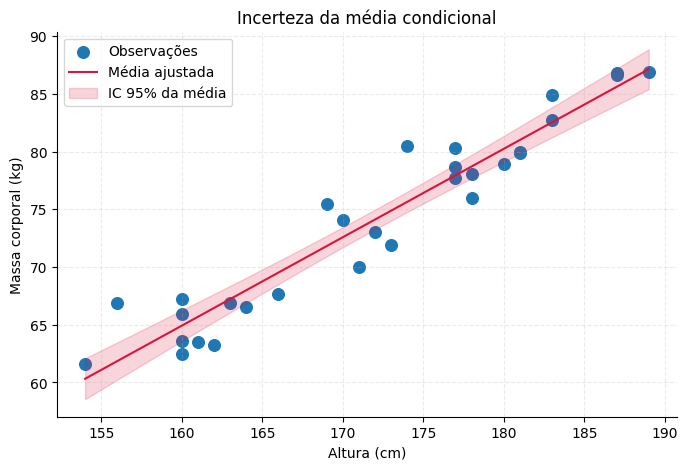

In [14]:
# Cria uma grade de alturas para desenhar curvas suaves de incerteza.
height_grid = pd.DataFrame({"height": np.linspace(sample["height"].min(), sample["height"].max(), 100)})
height_grid_X = sm.add_constant(height_grid, has_constant="add")
pred_grid = fit.get_prediction(height_grid_X).summary_frame(alpha=0.05)
pred_grid = pred_grid[["mean", "mean_se", "mean_ci_lower", "mean_ci_upper"]]

# Visualiza a média ajustada e o intervalo de confiança da média condicional.
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(sample["height"], sample["weight"], s=70, label="Observações")
ax.plot(height_grid["height"], pred_grid["mean"], color="crimson", label="Média ajustada")
ax.fill_between(height_grid["height"], pred_grid["mean_ci_lower"], pred_grid["mean_ci_upper"], color="crimson", alpha=0.18, label="IC 95% da média")
ax.set_title("Incerteza da média condicional")
ax.set_xlabel("Altura (cm)")
ax.set_ylabel("Massa corporal (kg)")
ax.legend()
plt.show()

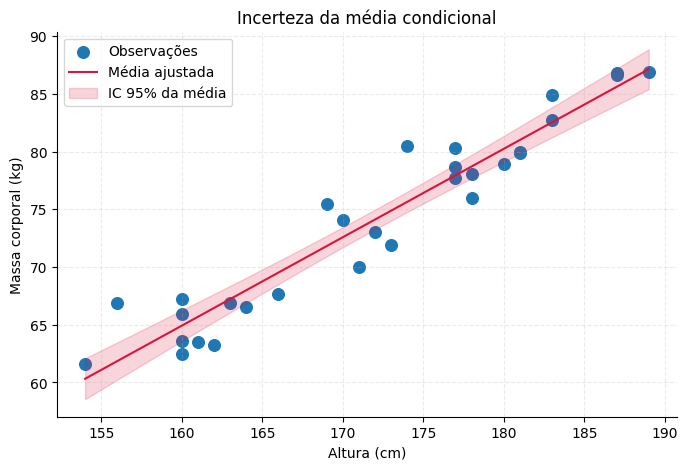

In [15]:
# Cria uma grade de alturas para desenhar curvas suaves de incerteza.
height_grid = pd.DataFrame({"height": np.linspace(sample["height"].min(), sample["height"].max(), 100)})
height_grid_X = sm.add_constant(height_grid, has_constant="add")
pred_grid = fit.get_prediction(height_grid_X).summary_frame(alpha=0.05)
pred_grid = pred_grid[["mean", "mean_se", "mean_ci_lower", "mean_ci_upper"]]

# Visualiza a média ajustada e o intervalo de confiança da média condicional.
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(sample["height"], sample["weight"], s=70, label="Observações")
ax.plot(height_grid["height"], pred_grid["mean"], color="crimson", label="Média ajustada")
ax.fill_between(height_grid["height"], pred_grid["mean_ci_lower"], pred_grid["mean_ci_upper"], color="crimson", alpha=0.18, label="IC 95% da média")
ax.set_title("Incerteza da média condicional")
ax.set_xlabel("Altura (cm)")
ax.set_ylabel("Massa corporal (kg)")
ax.legend()
plt.show()

**Figura 4 - Intervalo de confiança da média condicional no modelo de regressão linear simples.** A figura apresenta a média ajustada e o intervalo de confiança de 95% para a média condicional. A faixa sombreada representa a incerteza na estimação do valor médio esperado da massa corporal para cada valor de altura observado na amostra. Fonte: SOGA-Py, 2026.

## **Coeficiente de Determinação**

O coeficiente de determinação $R^2$ mede a proporção da variabilidade total da variável resposta que é explicada pelo modelo linear ajustado:

$$R^2 = 1 - \frac{SQ_{res}}{SQ_{tot}},$$

em que $SQ_{res}$ é a soma dos quadrados dos resíduos e $SQ_{tot}$ é a soma dos quadrados totais em relação à média da variável resposta.

Um $R^2$ elevado não garante validade inferencial, adequação causal ou ausência de problemas diagnósticos. Ele deve ser interpretado em conjunto com a análise dos resíduos e com o contexto substantivo do problema.


In [16]:
# Calcula manualmente R2 pela decomposição da soma de quadrados.
ss_res = np.sum(fit.resid ** 2)
ss_tot = np.sum((sample["weight"] - sample["weight"].mean()) ** 2)
r2_manual = 1 - ss_res / ss_tot

# Compara o cálculo manual com os valores retornados pelo statsmodels.
pd.Series(
    {
        "SQ_residual": ss_res,
        "SQ_total": ss_tot,
        "R2_manual": r2_manual,
        "R2_statsmodels": fit.rsquared,
        "R2_ajustado": fit.rsquared_adj,
    }
).round(4)


SQ_residual        148.5788
SQ_total          1870.0667
R2_manual            0.9205
R2_statsmodels       0.9205
R2_ajustado          0.9177
dtype: float64

## **Diagnóstico por Resíduos do Modelo Inicial**

Os resíduos são definidos por:

$$e_i = y_i - \hat{y}_i.$$

Eles representam a discrepância observada entre a resposta observada e o valor ajustado pelo modelo. A análise de resíduos é essencial para avaliar linearidade, homocedasticidade, normalidade aproximada dos erros e presença de observações atípicas ou influentes.



### **Termos Diagnósticos da Tabela `summary()`**

Os termos abaixo não são necessários para interpretar os coeficientes do modelo, mas ajudam a avaliar a adequação dos resíduos e possíveis problemas numéricos. Eles devem ser lidos em conjunto com os gráficos diagnósticos apresentados nesta seção.

| Termo no `summary()` | Tradução técnica | Interpretação no modelo | Cuidado de leitura |
| --- | --- | --- | --- |
| `Omnibus` | Teste global de normalidade dos resíduos | Avalia desvios da normalidade residual. | Em amostras pequenas, pode ter baixo poder; em amostras grandes, detecta desvios pequenos. |
| `Prob(Omnibus)` | Valor-p do teste Omnibus | Valor-p associado ao teste global de normalidade. | Deve ser complementado por gráficos, como QQ-plot. |
| `Skew` | Assimetria dos resíduos | Mede assimetria da distribuição residual. | Valores distantes de zero sugerem assimetria. |
| `Kurtosis` | Curtose dos resíduos | Mede o peso relativo das caudas da distribuição residual. | Valores elevados podem indicar caudas pesadas ou observações extremas. |
| `Jarque-Bera` | Teste Jarque-Bera | Teste de normalidade baseado em assimetria e curtose. | Não substitui inspeção gráfica dos resíduos. |
| `Prob(JB)` | Valor-p do teste Jarque-Bera | Valor-p associado ao teste Jarque-Bera. | Deve ser interpretado como diagnóstico, não como decisão automática. |
| `Durbin-Watson` | Estatística de Durbin-Watson | Diagnóstico de autocorrelação serial dos resíduos. | É mais relevante quando há ordem temporal ou espacial nas observações. |
| `Cond. No.` | Número de condição | Indicador de problema numérico, escala das variáveis ou colinearidade. | Em RLS, valores altos podem refletir escala da preditora; não implicam automaticamente erro do modelo. |


In [17]:
# Obtém resíduos padronizados e alavancagem do modelo ajustado.
influence = fit.get_influence()

# Consolida as principais variáveis diagnósticas em uma única tabela.
diagnostics = pd.DataFrame(
    {
        "height": sample["height"],
        "weight": sample["weight"],
        "fitted": fit.fittedvalues,
        "residual": fit.resid,
        "standardized_residual": influence.resid_studentized_internal,
        "studentized_residual": influence.resid_studentized_external,
        "leverage": influence.hat_matrix_diag,
    }
)

diagnostics.head().round(4)


,height,weight,fitted,residual,standardized_residual,studentized_residual,leverage
0,154,61.6,60.3135,1.2865,0.6026,0.5956,0.1411
1,156,66.9,61.8467,5.0533,2.3361,2.5566,0.1182
2,160,67.2,64.9131,2.2869,1.0354,1.0368,0.0806
3,160,65.9,64.9131,0.9869,0.4468,0.4403,0.0806
4,160,63.6,64.9131,-1.3131,-0.5945,-0.5875,0.0806


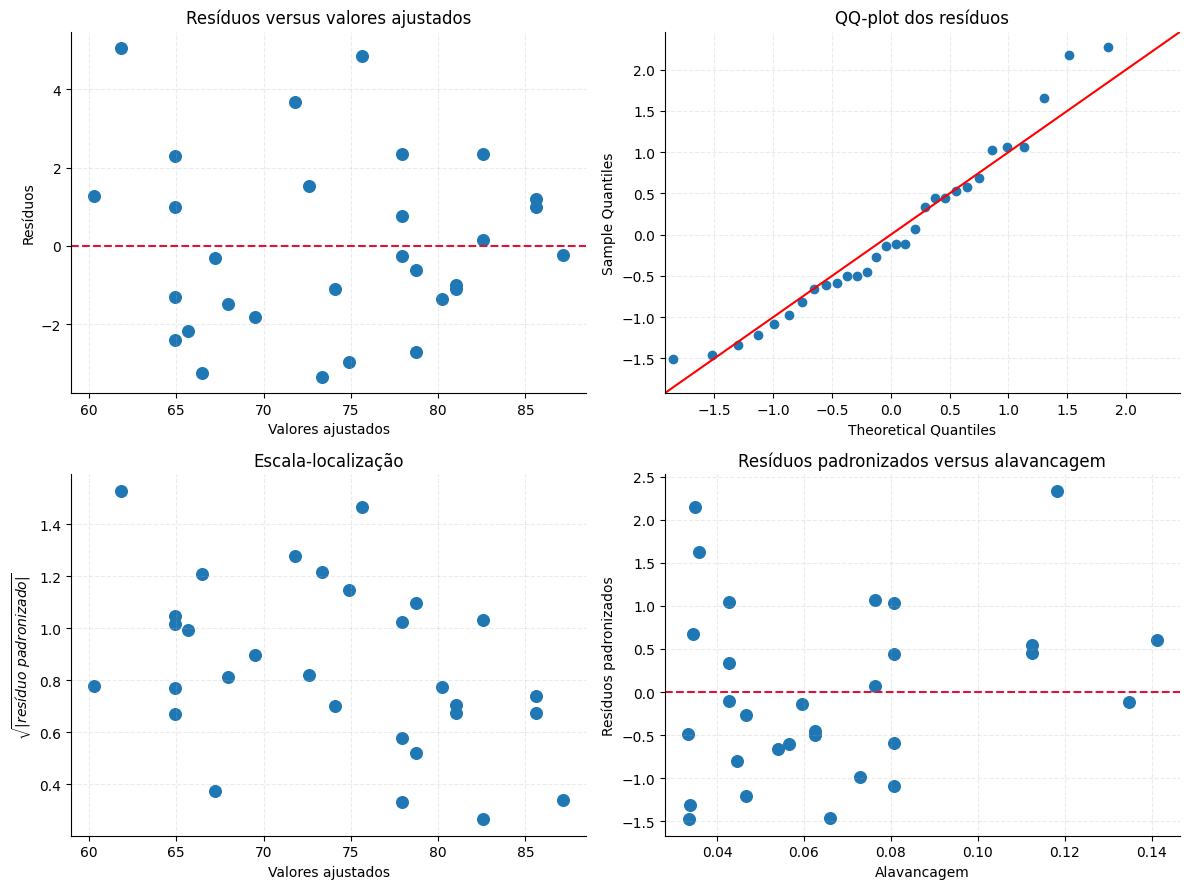

In [18]:
# Organiza quatro gráficos diagnósticos clássicos em uma matriz 2x2.
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# Verifica padrão sistemático nos resíduos em relação aos valores ajustados.
axes[0, 0].scatter(fit.fittedvalues, fit.resid, s=70)
axes[0, 0].axhline(0, color="crimson", linestyle="--")
axes[0, 0].set_title("Resíduos versus valores ajustados")
axes[0, 0].set_xlabel("Valores ajustados")
axes[0, 0].set_ylabel("Resíduos")

# Compara a distribuição dos resíduos com a normal teórica.
sm.qqplot(fit.resid, line="45", fit=True, ax=axes[0, 1])
axes[0, 1].set_title("QQ-plot dos resíduos")

# Avalia indícios de variância não constante ao longo dos valores ajustados.
axes[1, 0].scatter(fit.fittedvalues, np.sqrt(np.abs(diagnostics["standardized_residual"])), s=70)
axes[1, 0].set_title("Escala-localização")
axes[1, 0].set_xlabel("Valores ajustados")
axes[1, 0].set_ylabel(r"$\sqrt{|resíduo\ padronizado|}$")

# Relaciona magnitude dos resíduos padronizados com alavancagem.
axes[1, 1].scatter(diagnostics["leverage"], diagnostics["standardized_residual"], s=70)
axes[1, 1].axhline(0, color="crimson", linestyle="--")
axes[1, 1].set_title("Resíduos padronizados versus alavancagem")
axes[1, 1].set_xlabel("Alavancagem")
axes[1, 1].set_ylabel("Resíduos padronizados")

plt.tight_layout()
plt.show()


**Figura 5 - Painel de diagnósticos residuais do modelo de regressão.** A figura reúne resíduos versus valores ajustados, QQ-plot, escala-localização e resíduos padronizados versus alavancagem. O conjunto de gráficos permite avaliar linearidade, normalidade aproximada dos resíduos, homocedasticidade e observações com alta alavancagem. Fonte: SOGA-Py, 2026.


## **Aplicação Prática: API, Condições Socioeconômicas e Proficiência em Inglês**

Esta aplicação utiliza o dataset `api.csv`, descrito em `api_doc.txt`, para estudar o desempenho acadêmico de escolas da Califórnia. A variável resposta será o **Academic Performance Index em 2000** (`API00`), índice numérico de desempenho escolar na escala de 200 a 1.000.

A hipótese de pesquisa principal é que o desempenho acadêmico está associado às condições socioeconômicas dos estudantes. No dataset, essa hipótese será operacionalizada por `REFS`, percentual de estudantes elegíveis para refeição subsidiada. Como dimensão contextual complementar, será analisado `NPI`, percentual de estudantes não proficientes em inglês.

A análise será restrita às escolas fundamentais (`TIPO == "Fundamental"`) para reduzir heterogeneidade entre níveis escolares. O modelo com `REFS` será o modelo principal da hipótese socioeconômica. O modelo com `NPI` será uma comparação contextual. O modelo com `REFS` e `NPI` será apresentado como **regressão múltipla**, não como RLS.


### **Descrição do dataset**

#### **Descrição**
O API é um índice numérico na escala de 200 a 1.000 que indica o desempenho estudantil de uma escola ou distrito em testes anuais. O API é calculado para toda a escola, incluindo alunos desfavorecidos socioeconômicos, alunos com deficiência físico-motora e não proficientes em inglês [1].

As pontuações do API para escolas de mesma graduação (ensino fundamental, médio e superior) são classificadas em 'decis', com 1 representando os 10% de escolas com desempenho mais baixo e 10 os 10% de desempenho mais alto. As escolas têm dois rankings: (1) um ranking estadual que compara cada escola com todas as outras escolas do mesmo tipo no estado e (2) um ranking de escolas semelhantes que compara cada escola com 100 outras com populações de alunos similares e outras características [1].

O Conselho Estadual de Educação da California* definiu a meta de API estadual em 800 de 1.000. A Lei de responsabilidade das escolas públicas exige que a maioria das escolas melhore seu desempenho a cada ano em 5% da diferença entre sua API e a meta estadual de 800, com uma meta mínima de crescimento de cinco pontos [1].

#### **Formato**
Dataframe com 5423 observações (linhas) e 11 variáveis (colunas).

- **ID:** Identificação única da escola.
- **TIPO:** Nível de ensino da escola (fundamental, medio e superior).
- **NOME:** Nome da escola (15 caracteres).
- **API00:** Índice de desempenho acadêmico em 2000.
- **API99:** Índice de desempenho acadêmico em 1999.
- **META:** Meta de crescimento no API.
- **REFS:** Porcentagem de alunos elegíveis para refeição subsidiada.
- **NPI:** Porcentagem de alunos não proficientes em inglês.
- **EDU:** Média do nível de educação dos pais.
- **TEST_INSC:** número de alunos inscritos.
- **TESTNUM:** número de alunos testados para o API.

#### **Fontes**

Os dados foram obtidos pela pesquisa do setor acadêmico da Universidade da Califórnia em Los Angeles (UCLA).
[1] https://www.ed-data.org/article/Understanding-the-Academic-Performance-Index-(API)

Referência
O programa API foi descontinuado no final de 2018 e demais informações estão em https://www.cde.ca.gov/re/pr/api.asp

#### **Observações**

Califórnia é um dos 50 estados dos Estados Unidos, localizado na região dos estados do Pacífico. É o estado mais populoso do país, com 39.538.223 habitantes e o terceiro em extensão territorial, superado apenas pelo Alasca e pelo Texas (Wikipedia, 2021).

### **Pergunta de Pesquisa e Hipóteses**

**Pergunta de pesquisa:** entre escolas fundamentais da Califórnia, como condições socioeducacionais dos alunos se associam ao desempenho acadêmico medido pelo API em 2000?

Modelo principal:

$$API00_i = \beta_0 + \beta_1REFS_i + \varepsilon_i$$

**Hipótese de pesquisa principal:** quanto **maior o percentual** de alunos elegíveis para refeição subsidiada, **menor** tende a ser o API em 2000.

Modelo complementar simples:

$$API00_i = \beta_0 + \beta_1NPI_i + \varepsilon_i$$

**Hipótese de pesquisa complementar:** quanto maior o percentual de alunos não proficientes em inglês, menor tende a ser o API em 2000.

Modelo complementar múltiplo:

$$API00_i = \beta_0 + \beta_1REFS_i + \beta_2NPI_i + \varepsilon_i$$

No modelo múltiplo, os coeficientes são associações parciais: cada preditor é interpretado mantendo constante o outro preditor. Nenhum dos modelos autoriza interpretação causal sem pressupostos adicionais.


### **Justificativa do Recorte Analítico**

Antes de ajustar os modelos, é necessário verificar se os tipos de escola apresentam características semelhantes. Caso escolas fundamentais, médias e superiores tenham composições muito distintas, um único modelo com todos os tipos pode misturar diferenças entre estratos escolares com associações entre variáveis socioeducacionais e desempenho.

In [19]:
# Carrega o dataset API e inspeciona as variáveis usadas no recorte analítico.
api = pd.read_csv("../../dataset/api.csv")
variaveis_api = ["TIPO", "API00", "REFS", "NPI"]

api[variaveis_api].head()

,TIPO,API00,REFS,NPI
0,Superior,731,14,16
1,Superior,622,20,18
2,Medio,622,55,25
3,Fundamental,774,35,26
4,Fundamental,811,15,9


In [20]:
# Conta quantas escolas existem em cada tipo.
n_escolas = api["TIPO"].value_counts().sort_index()

n_escolas

TIPO
Fundamental    3812
Medio           897
Superior        714
Name: count, dtype: int64

In [21]:
# Calcula o percentual de cada tipo de escola na amostra.
percentual_amostra = 100 * n_escolas / len(api)

percentual_amostra.round(2)

TIPO
Fundamental    70.29
Medio          16.54
Superior       13.17
Name: count, dtype: float64

In [22]:
# Calcula médias por tipo de escola.
medias = api.groupby("TIPO")[["API00", "REFS", "NPI"]].mean()

medias.round(2)

,API00,REFS,NPI
TIPO,,,
Fundamental,641.94,58.42,28.24
Medio,630.88,48.33,20.91
Superior,622.56,32.54,15.08


In [23]:
# Calcula desvios-padrão por tipo de escola.
desvios = api.groupby("TIPO")[["API00", "REFS", "NPI"]].std()

desvios.round(2)

,API00,REFS,NPI
TIPO,,,
Fundamental,113.08,27.81,23.02
Medio,108.89,25.61,17.24
Superior,97.43,23.75,13.75


In [24]:
# Organiza os resultados parciais em uma tabela final.
resumo_tipo = pd.DataFrame(
    {
        "n_escolas": n_escolas,
        "percentual_amostra": percentual_amostra,
        "media_API00": medias["API00"],
        "desvio_API00": desvios["API00"],
        "media_REFS": medias["REFS"],
        "desvio_REFS": desvios["REFS"],
        "media_NPI": medias["NPI"],
        "desvio_NPI": desvios["NPI"],
    }
)

resumo_tipo.round(2)

,n_escolas,percentual_amostra,media_API00,desvio_API00,media_REFS,desvio_REFS,media_NPI,desvio_NPI
TIPO,,,,,,,,
Fundamental,3812,70.29,641.94,113.08,58.42,27.81,28.24,23.02
Medio,897,16.54,630.88,108.89,48.33,25.61,20.91,17.24
Superior,714,13.17,622.56,97.43,32.54,23.75,15.08,13.75


**Observação sobre `describe()`:** o método `describe()` também poderia ser usado em uma exploração inicial dos dados, pois resume automaticamente contagem, média, desvio-padrão, mínimo, quartis e máximo. Nesta aula, a tabela foi construída manualmente para manter apenas as estatísticas necessárias à justificativa do recorte analítico e tornar cada etapa do cálculo mais transparente.

In [25]:
# Calcula estatísticas descritivas para as variáveis numéricas do recorte.
api[variaveis_api].describe().round(2)

,API00,REFS,NPI
count,5423.00,5423.00,5423.00
mean,637.56,53.34,25.30
std,110.66,28.38,21.66
min,346.00,0.00,0.00
25%,552.00,29.00,7.00
50%,645.00,53.00,19.00
75%,726.00,78.00,38.00
max,878.00,100.00,95.00


A tabela mostra que os tipos de escola não têm a mesma composição na amostra nem os mesmos níveis médios de desempenho e de características contextuais. As escolas fundamentais representam a maior parte da base, enquanto escolas médias e superiores aparecem em proporções menores e com médias distintas de `API00`, `REFS` e `NPI`.

Por essa razão, o filtro para `TIPO == "Fundamental"` define uma **população analítica mais homogênea** para a aula. A conclusão dos modelos seguintes deve ser interpretada como válida para escolas fundamentais da base analisada, e não como uma generalização automática para todos os tipos de escola. Uma análise conjunta de todos os tipos exigiria incluir `TIPO` como variável categórica e, possivelmente, avaliar interações entre `TIPO` e os preditores.

In [26]:
# Usa o dataset API carregado na justificativa do recorte analítico.
# Mantém apenas escolas do ensino fundamental.
df = api[api["TIPO"] == "Fundamental"]
df.head()

,ID,TIPO,NOME,API00,API99,META,EDU,TEST_INSC,TEST_NUM,REFS,NPI
3,1611196090005,Fundamental,Lum (Donald D.),774,732,3,3.32,330,272,35,26
4,1611196090013,Fundamental,Edison Elementa,811,784,1,3.76,233,216,15,9
5,1611196090021,Fundamental,Otis (Frank) El,780,725,4,3.44,276,247,25,18
6,1611196090039,Fundamental,Franklin Elemen,808,765,2,3.23,180,167,22,9
7,1611196090047,Fundamental,Haight Elementa,739,667,7,2.75,363,292,50,35


In [27]:
# Resume a amostra usada nos três modelos aplicados.
pd.Series(
    {
        "n_escolas_fundamentais": len(df),
        "media_API00": df["API00"].mean(),
        "media_REFS": df["REFS"].mean(),
        "media_NPI": df["NPI"].mean(),
    }
).round(2)

n_escolas_fundamentais    3812.00
media_API00                641.94
media_REFS                  58.42
media_NPI                   28.24
dtype: float64

In [28]:
# Calcula a matriz de correlação entre desempenho e proxies contextuais.
df[["API00", "REFS", "NPI"]].corr().round(3)


,API00,REFS,NPI
API00,1.000,-0.847,-0.725
REFS,-0.847,1.000,0.746
NPI,-0.725,0.746,1.000


A matriz de correlação permite verificar a direção e a intensidade da associação linear entre as variáveis antes do ajuste dos modelos. Espera-se correlação negativa entre `API00` e as duas proxies contextuais. Também é importante observar a correlação entre `REFS` e `NPI`, pois associação elevada entre preditores exige cautela na interpretação do modelo múltiplo.


### **Modelo 1: API e Condição Socioeconômica (`REFS`)**

O primeiro modelo é a análise principal da aplicação. Nele, `REFS` representa o percentual de estudantes elegíveis para refeição subsidiada, usado como proxy de condição socioeconômica da escola.


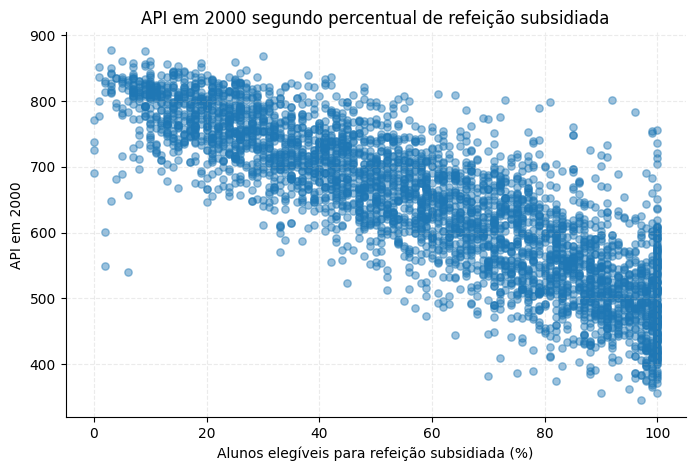

In [29]:
# Visualiza a relação bivariada entre REFS e API00.
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df["REFS"], df["API00"], alpha=0.45, s=28)
ax.set_title("API em 2000 segundo percentual de refeição subsidiada")
ax.set_xlabel("Alunos elegíveis para refeição subsidiada (%)")
ax.set_ylabel("API em 2000")
plt.show()


**Figura 6 - Diagrama de dispersão entre REFS e API00.** A figura apresenta a associação entre o percentual de alunos elegíveis para refeição subsidiada e o desempenho acadêmico das escolas fundamentais. Observa-se tendência negativa, indicando que escolas com maior percentual de estudantes elegíveis para refeição subsidiada tendem a apresentar menor API em 2000. Fonte: SOGA-Py, 2026.


In [30]:
# Ajusta o modelo principal por mínimos quadrados: API00 ~ REFS.
X_refs = sm.add_constant(df[["REFS"]], has_constant="add")
fit_refs = sm.OLS(df["API00"], X_refs).fit()

print(fit_refs.summary())

                            OLS Regression Results                            
Dep. Variable:                  API00   R-squared:                       0.718
Model:                            OLS   Adj. R-squared:                  0.718
Method:                 Least Squares   F-statistic:                     9704.
Date:                Sun, 31 May 2026   Prob (F-statistic):               0.00
Time:                        20:31:21   Log-Likelihood:                -21019.
No. Observations:                3812   AIC:                         4.204e+04
Df Residuals:                    3810   BIC:                         4.205e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        843.2162      2.263    372.629      0.0

In [31]:
# Gera valores ajustados ao longo da escala observada de REFS.
refs_grid = pd.DataFrame({"REFS": np.linspace(df["REFS"].min(), df["REFS"].max(), 100)})
refs_grid_X = sm.add_constant(refs_grid, has_constant="add")
refs_pred = fit_refs.get_prediction(refs_grid_X).summary_frame(alpha=0.05)
refs_pred = refs_pred[["mean", "mean_se", "mean_ci_lower", "mean_ci_upper"]]

print(refs_pred.head().round(2))

     mean  mean_se  mean_ci_lower  mean_ci_upper
0  843.22     2.26         838.78         847.65
1  839.74     2.23         835.36         844.11
2  836.26     2.20         831.94         840.57
3  832.78     2.17         828.53         837.03
4  829.30     2.14         825.11         833.48


A tabela apresenta valores ajustados do modelo `API00 ~ REFS` para uma sequência de valores de `REFS` dentro da escala observada nas escolas fundamentais.

- `mean`: valor médio estimado de `API00` para escolas com aquele valor de `REFS`.
- `mean_se`: erro padrão da média estimada; valores menores indicam maior precisão na estimativa da média condicional.
- `mean_ci_lower` e `mean_ci_upper`: limites inferior e superior do intervalo de confiança de 95% para a média de `API00` naquele valor de `REFS`.

Nos primeiros valores da tabela, que correspondem aos menores percentuais observados de alunos elegíveis para refeição subsidiada, o modelo estima valores médios de `API00` próximos de 843, 840 e 836 pontos. À medida que `REFS` aumenta, o valor ajustado de `API00` diminui, coerentemente com o coeficiente angular negativo estimado para `REFS`. O intervalo de confiança informa a incerteza associada à média condicional estimada para cada valor de `REFS`.

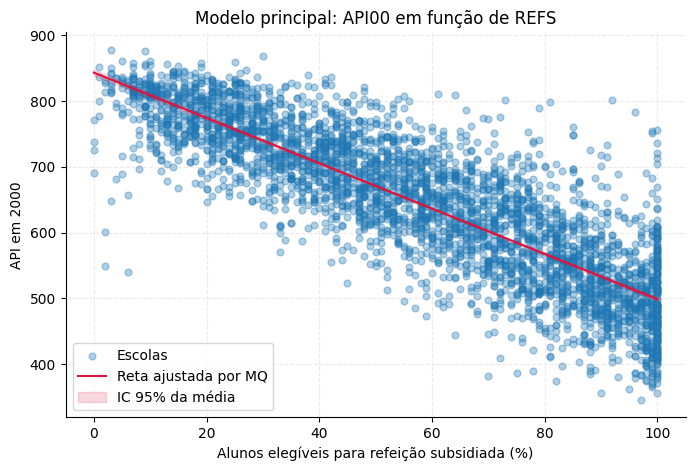

In [32]:
# Visualiza a reta ajustada por MQ e o intervalo de confiança da média condicional.
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df["REFS"], df["API00"], alpha=0.35, s=24, label="Escolas")
ax.plot(refs_grid["REFS"], refs_pred["mean"], color="crimson", label="Reta ajustada por MQ")
ax.fill_between(refs_grid["REFS"], refs_pred["mean_ci_lower"], refs_pred["mean_ci_upper"], color="crimson", alpha=0.16, label="IC 95% da média")
ax.set_title("Modelo principal: API00 em função de REFS")
ax.set_xlabel("Alunos elegíveis para refeição subsidiada (%)")
ax.set_ylabel("API em 2000")
ax.legend()
plt.show()

**Figura 7 - Reta ajustada do modelo API00 em função de REFS.** A figura mostra o ajuste por mínimos quadrados do modelo principal. A inclinação negativa indica que aumentos no percentual de alunos elegíveis para refeição subsidiada estão associados a reduções médias no API em 2000, no contexto da análise bivariada. Fonte: SOGA-Py, 2026.


In [33]:
# Resume os principais resultados inferenciais do modelo principal.
pd.DataFrame(
    {
        "coeficiente": fit_refs.params,
        "erro_padrao": fit_refs.bse,
        "t": fit_refs.tvalues,
        "valor_p": fit_refs.pvalues,
        "IC_95_inf": fit_refs.conf_int()[0],
        "IC_95_sup": fit_refs.conf_int()[1],
    }
).round(4)


,coeficiente,erro_padrao,t,valor_p,IC_95_inf,IC_95_sup
const,843.2162,2.2629,372.6287,0.0,838.7796,847.6528
REFS,-3.4455,0.0350,-98.5089,0.0,-3.5140,-3.3769


No modelo principal, o coeficiente angular de `REFS` estima a variação média esperada no API para aumento de um ponto percentual no percentual de alunos elegíveis para refeição subsidiada. Como o modelo é bivariado, essa estimativa descreve associação linear, não efeito causal.


### **Modelo 2: API e Não Proficiência em Inglês (`NPI`)**

O segundo modelo é complementar. `NPI` representa o percentual de estudantes não proficientes em inglês. Essa variável não substitui a hipótese socioeconômica principal, mas permite comparar outra dimensão contextual associada ao desempenho escolar.


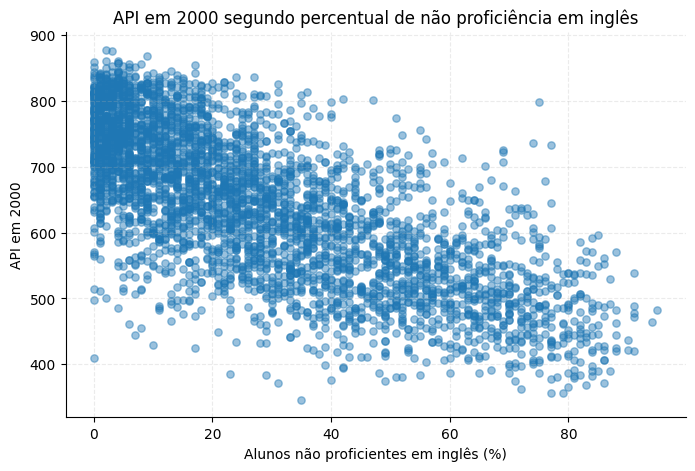

In [34]:
# Visualiza a relação bivariada entre NPI e API00.
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df["NPI"], df["API00"], alpha=0.45, s=28)
ax.set_title("API em 2000 segundo percentual de não proficiência em inglês")
ax.set_xlabel("Alunos não proficientes em inglês (%)")
ax.set_ylabel("API em 2000")
plt.show()


**Figura 8 - Diagrama de dispersão entre NPI e API00.** A figura apresenta a associação entre o percentual de alunos não proficientes em inglês e o API em 2000. Observa-se tendência negativa, sugerindo que escolas com maior percentual de alunos não proficientes em inglês tendem a apresentar menor desempenho médio no índice. Fonte: SOGA-Py, 2026.


In [35]:
# Ajusta o modelo complementar por mínimos quadrados: API00 ~ NPI.
X_npi = sm.add_constant(df[["NPI"]], has_constant="add")
fit_npi = sm.OLS(df["API00"], X_npi).fit()

print(fit_npi.summary())


                            OLS Regression Results                            
Dep. Variable:                  API00   R-squared:                       0.525
Model:                            OLS   Adj. R-squared:                  0.525
Method:                 Least Squares   F-statistic:                     4219.
Date:                Sun, 31 May 2026   Prob (F-statistic):               0.00
Time:                        20:31:21   Log-Likelihood:                -22011.
No. Observations:                3812   AIC:                         4.403e+04
Df Residuals:                    3810   BIC:                         4.404e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        742.5381      1.998    371.694      0.0

In [36]:
# Gera valores ajustados ao longo da escala observada de NPI.
npi_grid = pd.DataFrame({"NPI": np.linspace(df["NPI"].min(), df["NPI"].max(), 100)})
npi_grid_X = sm.add_constant(npi_grid, has_constant="add")
npi_pred = fit_npi.get_prediction(npi_grid_X).summary_frame(alpha=0.05)
npi_pred = npi_pred[["mean", "mean_se", "mean_ci_lower", "mean_ci_upper"]]

print(npi_pred.head().round(2))

     mean  mean_se  mean_ci_lower  mean_ci_upper
0  742.54     2.00         738.62         746.45
1  739.12     1.96         735.28         742.96
2  735.70     1.92         731.94         739.46
3  732.28     1.88         728.60         735.97
4  728.87     1.84         725.26         732.47


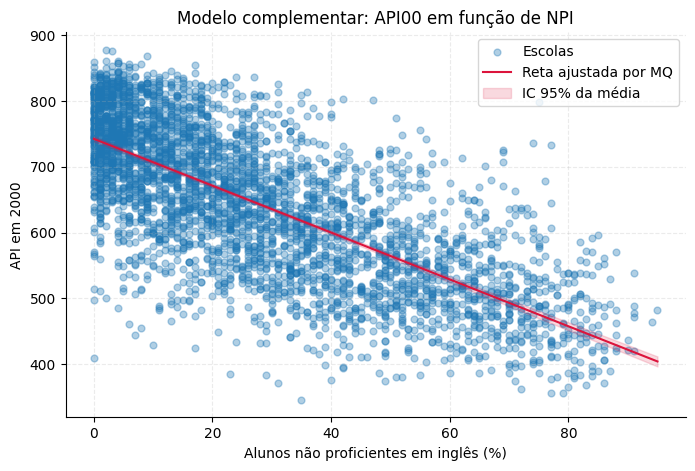

In [37]:
# Visualiza a reta ajustada por MQ e o intervalo de confiança da média condicional.
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df["NPI"], df["API00"], alpha=0.35, s=24, label="Escolas")
ax.plot(npi_grid["NPI"], npi_pred["mean"], color="crimson", label="Reta ajustada por MQ")
ax.fill_between(npi_grid["NPI"], npi_pred["mean_ci_lower"], npi_pred["mean_ci_upper"], color="crimson", alpha=0.16, label="IC 95% da média")
ax.set_title("Modelo complementar: API00 em função de NPI")
ax.set_xlabel("Alunos não proficientes em inglês (%)")
ax.set_ylabel("API em 2000")
ax.legend()
plt.show()

**Figura 9 - Reta ajustada do modelo API00 em função de NPI.** A figura mostra o ajuste por mínimos quadrados do modelo complementar. A inclinação negativa indica associação inversa entre não proficiência em inglês e API em 2000, mas a interpretação deve considerar que `NPI` também se relaciona a outros fatores contextuais da escola. Fonte: SOGA-Py, 2026.


In [38]:
# Resume os principais resultados inferenciais do modelo complementar.
pd.DataFrame(
    {
        "coeficiente": fit_npi.params,
        "erro_padrao": fit_npi.bse,
        "t": fit_npi.tvalues,
        "valor_p": fit_npi.pvalues,
        "IC_95_inf": fit_npi.conf_int()[0],
        "IC_95_sup": fit_npi.conf_int()[1],
    }
).round(4)


,coeficiente,erro_padrao,t,valor_p,IC_95_inf,IC_95_sup
const,742.5381,1.9977,371.6937,0.0,738.6214,746.4548
NPI,-3.5616,0.0548,-64.9529,0.0,-3.6692,-3.4541


### **Modelo 3: Regressão Múltipla com `REFS` e `NPI`**

O terceiro modelo inclui simultaneamente `REFS` e `NPI`. Ele não é regressão linear simples; trata-se de uma regressão linear múltipla. Seu objetivo é comparar a associação parcial de cada variável com `API00`, mantendo constante a outra variável.


In [39]:
# Ajusta o modelo múltiplo: API00 ~ REFS + NPI.
X_multi = sm.add_constant(df[["REFS", "NPI"]], has_constant="add")
fit_multi = sm.OLS(df["API00"], X_multi).fit()

# Resume os principais resultados inferenciais do modelo múltiplo.
pd.DataFrame(
    {
        "coeficiente": fit_multi.params,
        "erro_padrao": fit_multi.bse,
        "t": fit_multi.tvalues,
        "valor_p": fit_multi.pvalues,
        "IC_95_inf": fit_multi.conf_int()[0],
        "IC_95_sup": fit_multi.conf_int()[1],
    }
).round(4)


,coeficiente,erro_padrao,t,valor_p,IC_95_inf,IC_95_sup
const,835.1827,2.2360,373.5220,0.0,830.7989,839.5665
REFS,-2.8113,0.0507,-55.4560,0.0,-2.9107,-2.7120
NPI,-1.0271,0.0613,-16.7664,0.0,-1.1472,-0.9070


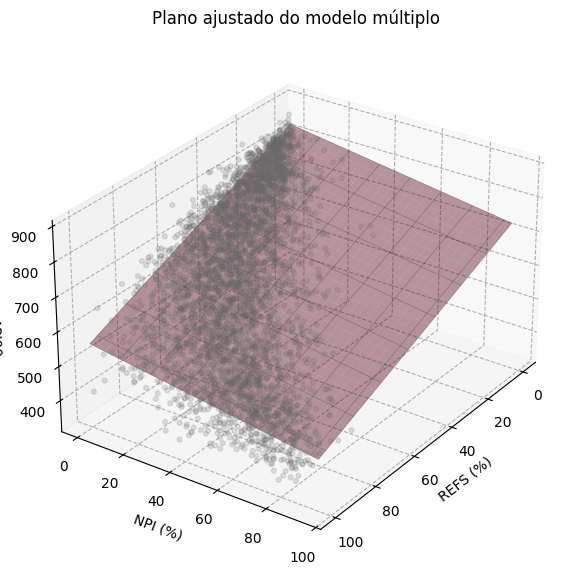

In [40]:
# Visualiza o plano ajustado do modelo múltiplo.
# Em regressão múltipla com dois preditores, o ajuste é um plano em 3D.
refs_seq = np.linspace(df["REFS"].min(), df["REFS"].max(), 30)
npi_seq = np.linspace(df["NPI"].min(), df["NPI"].max(), 30)
REFS_grid, NPI_grid = np.meshgrid(refs_seq, npi_seq)

grid_multi = pd.DataFrame(
    {
        "REFS": REFS_grid.ravel(),
        "NPI": NPI_grid.ravel(),
    }
)
grid_multi_X = sm.add_constant(grid_multi, has_constant="add")
API00_grid = fit_multi.predict(grid_multi_X).values.reshape(REFS_grid.shape)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    df["REFS"],
    df["NPI"],
    df["API00"],
    color="dimgray",
    alpha=0.18,
    s=12,
    label="Escolas",
)
ax.plot_surface(
    REFS_grid,
    NPI_grid,
    API00_grid,
    color="crimson",
    alpha=0.42,
    linewidth=0,
    antialiased=True,
)
ax.plot_wireframe(
    REFS_grid,
    NPI_grid,
    API00_grid,
    color="black",
    alpha=0.35,
    linewidth=0.4,
    rstride=4,
    cstride=4,
)

ax.set_title("Plano ajustado do modelo múltiplo")
ax.set_xlabel("REFS (%)")
ax.set_ylabel("NPI (%)")
ax.set_zlabel("API00")
ax.view_init(elev=28, azim=35)
ax.set_box_aspect((1.25, 1.0, 0.75))
plt.show()


**Figura 10 - Plano ajustado do modelo múltiplo.** A figura apresenta o plano estimado pela regressão múltipla `API00 ~ REFS + NPI`. Os pontos representam escolas observadas, e o plano representa os valores médios ajustados de `API00` para combinações de `REFS` e `NPI`. A inclinação do plano indica associações parciais entre cada preditor e o desempenho acadêmico. Fonte: SOGA-Py, 2026.

In [41]:
# Compara ajuste e erro residual dos três modelos.
model_summary = pd.DataFrame(
    [
        {
            "modelo": "API00 ~ REFS",
            "tipo": "RLS principal",
            "R2": fit_refs.rsquared,
            "R2_ajustado": fit_refs.rsquared_adj,
            "erro_padrao_residual": np.sqrt(fit_refs.mse_resid),
        },
        {
            "modelo": "API00 ~ NPI",
            "tipo": "RLS complementar",
            "R2": fit_npi.rsquared,
            "R2_ajustado": fit_npi.rsquared_adj,
            "erro_padrao_residual": np.sqrt(fit_npi.mse_resid),
        },
        {
            "modelo": "API00 ~ REFS + NPI",
            "tipo": "Regressão múltipla",
            "R2": fit_multi.rsquared,
            "R2_ajustado": fit_multi.rsquared_adj,
            "erro_padrao_residual": np.sqrt(fit_multi.mse_resid),
        },
    ]
)
model_summary.round(4)


,modelo,tipo,R2,R2_ajustado,erro_padrao_residual
0,API00 ~ REFS,RLS principal,0.7181,0.7180,60.0511
1,API00 ~ NPI,RLS complementar,0.5255,0.5253,77.9086
2,API00 ~ REFS + NPI,Regressão múltipla,0.7374,0.7373,57.9583


A comparação dos modelos permite separar duas ideias: `REFS` é a proxy principal da hipótese socioeconômica e tende a explicar mais variabilidade de `API00` quando analisada isoladamente; `NPI` representa uma dimensão contextual complementar. O modelo múltiplo pode aumentar o poder explicativo, mas seus coeficientes devem ser interpretados como associações parciais. Como `REFS` e `NPI` são positivamente correlacionadas, há indício de **colinearidade entre os preditores**. Portanto, a interpretação dos coeficientes do modelo múltiplo exige cautela, pois cada coeficiente representa uma associação parcial com `API00`, mantendo constante a outra variável.


## **Diagnóstico por Resíduos**

O diagnóstico dos resíduos dos modelos aplicados verifica se há padrões sistemáticos não capturados pela especificação linear. Serão avaliados resíduos versus valores ajustados, QQ-plots e erro padrão residual. A análise será mantida em nível básico, sem medidas avançadas de influência.


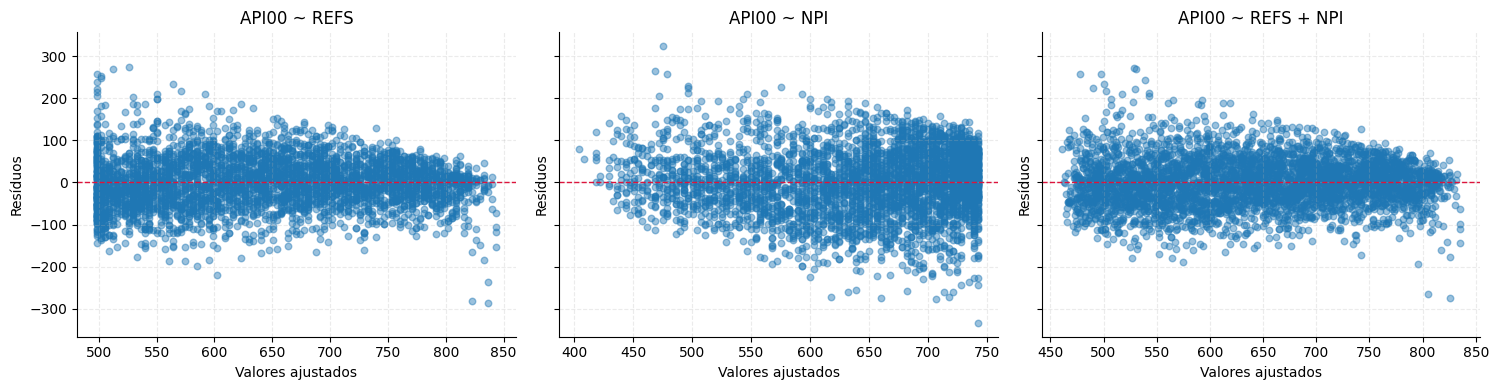

In [42]:
# Organiza resíduos e valores ajustados dos três modelos em formato longo.
api_diagnostics = pd.concat(
    [
        pd.DataFrame({"modelo": "API00 ~ REFS", "fitted": fit_refs.fittedvalues, "residual": fit_refs.resid}),
        pd.DataFrame({"modelo": "API00 ~ NPI", "fitted": fit_npi.fittedvalues, "residual": fit_npi.resid}),
        pd.DataFrame({"modelo": "API00 ~ REFS + NPI", "fitted": fit_multi.fittedvalues, "residual": fit_multi.resid}),
    ],
    ignore_index=True,
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, (model_name, group) in zip(axes, api_diagnostics.groupby("modelo", sort=False)):
    ax.scatter(group["fitted"], group["residual"], alpha=0.45, s=22)
    ax.axhline(0, color="crimson", linestyle="--", linewidth=1)
    ax.set_title(model_name)
    ax.set_xlabel("Valores ajustados")
    ax.set_ylabel("Resíduos")

plt.tight_layout()
plt.show()


**Figura 11 - Resíduos versus valores ajustados dos modelos API.** A figura compara os resíduos dos modelos `API00 ~ REFS`, `API00 ~ NPI` e `API00 ~ REFS + NPI`. No modelo com `REFS`, os resíduos se distribuem em torno de zero com menor dispersão que no modelo com `NPI`, indicando que a proporção de alunos elegíveis para refeição subsidiada captura parte importante da variação de `API00`. No modelo com `NPI`, a dispersão residual é mais ampla, sugerindo menor capacidade explicativa isolada da proficiência limitada em inglês quando comparada a `REFS`. No modelo múltiplo, a inclusão simultânea de `REFS` e `NPI` reduz moderadamente a dispersão residual em relação ao modelo principal, mas não elimina a variabilidade não explicada; por isso, os coeficientes devem ser lidos como associações parciais, sem interpretação causal. Fonte: SOGA-Py, 2026.


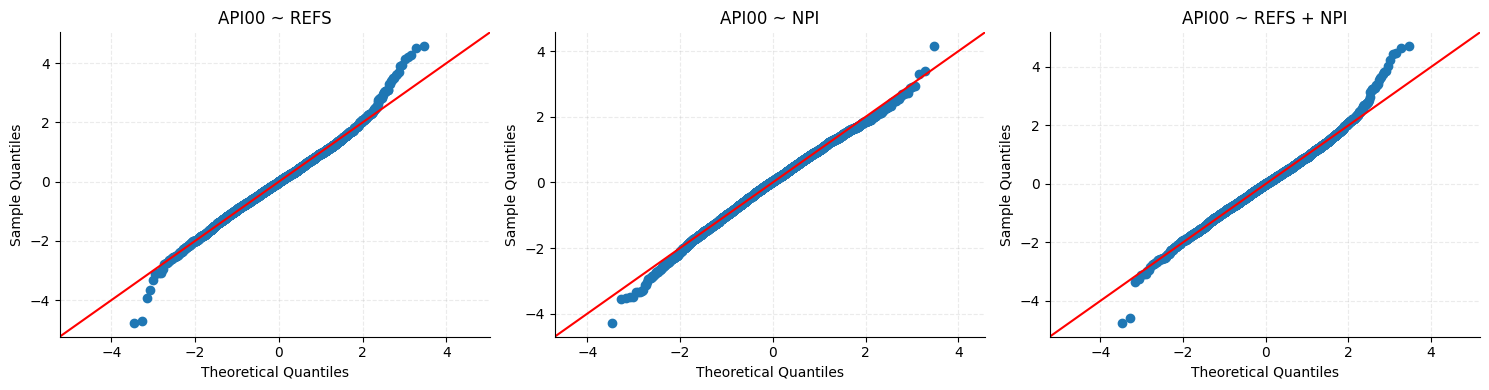

In [43]:
# Compara a normalidade aproximada dos resíduos por QQ-plot.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, fit_model, title in zip(
    axes,
    [fit_refs, fit_npi, fit_multi],
    ["API00 ~ REFS", "API00 ~ NPI", "API00 ~ REFS + NPI"],
):
    sm.qqplot(fit_model.resid, line="45", fit=True, ax=ax)
    ax.set_title(title)

plt.tight_layout()
plt.show()


**Figura 12 - QQ-plots dos resíduos dos modelos API.** A figura compara os quantis empíricos dos resíduos com os quantis esperados sob normalidade para os modelos `API00 ~ REFS`, `API00 ~ NPI` e `API00 ~ REFS + NPI`. No modelo com `REFS`, os pontos tendem a acompanhar a reta de referência na região central, mas há desvios nas extremidades, sugerindo resíduos com caudas mais acentuadas. No modelo com `NPI`, a dispersão residual é maior em termos de erro do modelo, mas o QQ-plot indica menor afastamento relativo nas caudas quando comparado aos modelos que incluem `REFS`; isso mostra que qualidade de ajuste e normalidade residual são critérios distintos. No modelo múltiplo, a inclusão de `REFS` e `NPI` reduz o erro residual, mas os desvios nas extremidades permanecem, indicando que a especificação linear melhora o ajuste médio sem tornar os resíduos perfeitamente compatíveis com a normalidade. Fonte: SOGA-Py, 2026.


In [44]:
# Compara o erro padrão residual como medida sintética da variabilidade não explicada.
model_summary[["modelo", "tipo", "erro_padrao_residual"]].round(4)


,modelo,tipo,erro_padrao_residual
0,API00 ~ REFS,RLS principal,60.0511
1,API00 ~ NPI,RLS complementar,77.9086
2,API00 ~ REFS + NPI,Regressão múltipla,57.9583


### **Identificação de Observações Atípicas**

Nesta aplicação, observações atípicas serão identificadas por meio dos **resíduos padronizados**. Como regra operacional simples, serão destacadas escolas com $|z_i| > 3$, isto é, resíduos padronizados com magnitude superior a três desvios-padrão residuais. Essa regra é apenas diagnóstica: uma observação não deve ser removida automaticamente sem justificativa substantiva.


In [45]:
# Conta observações com resíduos padronizados elevados em cada modelo.
modelos_api = {
    "API00 ~ REFS": fit_refs,
    "API00 ~ NPI": fit_npi,
    "API00 ~ REFS + NPI": fit_multi,
}

outlier_counts = []
for nome_modelo, modelo in modelos_api.items():
    residuos_padronizados = modelo.get_influence().resid_studentized_internal
    outlier_counts.append(
        {
            "modelo": nome_modelo,
            "n_observacoes": int(modelo.nobs),
            "abs_resid_padronizado_maior_2": int((np.abs(residuos_padronizados) > 2).sum()),
            "abs_resid_padronizado_maior_3": int((np.abs(residuos_padronizados) > 3).sum()),
            "percentual_maior_3": 100 * (np.abs(residuos_padronizados) > 3).mean(),
        }
    )

pd.DataFrame(outlier_counts).round(2)


,modelo,n_observacoes,abs_resid_padronizado_maior_2,abs_resid_padronizado_maior_3,percentual_maior_3
0,API00 ~ REFS,3812,187,32,0.84
1,API00 ~ NPI,3812,160,16,0.42
2,API00 ~ REFS + NPI,3812,176,29,0.76


In [46]:
# Lista as observações mais atípicas no modelo principal com REFS.
residuos_refs_padronizados = fit_refs.get_influence().resid_studentized_internal

outliers_refs = df.assign(
    valor_ajustado_REFS=fit_refs.fittedvalues,
    residuo_REFS=fit_refs.resid,
    residuo_padronizado_REFS=residuos_refs_padronizados,
    abs_residuo_padronizado_REFS=np.abs(residuos_refs_padronizados),
)

outliers_refs.sort_values("abs_residuo_padronizado_REFS", ascending=False).head(10).round(3)


,ID,TIPO,NOME,API00,API99,META,EDU,TEST_INSC,TEST_NUM,REFS,NPI,valor_ajustado_REFS,residuo_REFS,residuo_padronizado_REFS,abs_residuo_padronizado_REFS
3433,36676116035372,Fundamental,Lenwood Element,550,451,17,2.61,254,201,2,4,836.325,-286.325,-4.771,4.771
3430,36676116035307,Fundamental,Crestline Eleme,540,467,17,2.43,402,233,6,13,822.543,-282.543,-4.708,4.708
4205,38684786099154,Fundamental,Moscone (George,801,715,4,2.13,236,182,92,47,526.234,274.766,4.577,4.577
694,13631236008460,Fundamental,Hedrick (Margar,783,775,1,3.14,376,320,96,26,512.452,270.548,4.507,4.507
3284,34674396033930,Fundamental,Elder Creek Ele,756,714,4,1.98,496,408,100,55,498.670,257.330,4.287,4.287
2413,27659616109466,Fundamental,Steinbeck (John,754,723,4,3.22,407,346,99,14,502.115,251.885,4.196,4.196
4413,41689996044325,Fundamental,Costano Element,751,609,10,2.20,396,293,99,27,502.115,248.885,4.146,4.146
3949,37683386039366,Fundamental,Central Element,736,611,9,1.71,508,483,100,74,498.670,237.330,3.954,3.954
3432,36676116035356,Fundamental,Hinkley Element,601,536,13,1.91,323,207,2,33,836.325,-235.325,-3.921,3.921
166,1612596002018,Fundamental,Lincoln Element,799,756,2,2.27,427,407,81,75,564.134,234.866,3.912,3.912


In [47]:
# Compara os modelos originais com versões ajustadas sem |resíduo padronizado| > 3.
def compara_impacto_outliers(nome_modelo, resposta, preditores, modelo_original):
    residuos_padronizados = modelo_original.get_influence().resid_studentized_internal
    manter = np.abs(residuos_padronizados) <= 3

    X_sem_outliers = sm.add_constant(df.loc[manter, preditores], has_constant="add")
    modelo_sem_outliers = sm.OLS(df.loc[manter, resposta], X_sem_outliers).fit()

    linhas = []
    for parametro in modelo_original.params.index:
        linhas.append(
            {
                "modelo": nome_modelo,
                "parametro": parametro,
                "coef_original": modelo_original.params[parametro],
                "coef_sem_outliers": modelo_sem_outliers.params[parametro],
                "diferenca": modelo_sem_outliers.params[parametro] - modelo_original.params[parametro],
                "n_removido": int((~manter).sum()),
                "R2_original": modelo_original.rsquared,
                "R2_sem_outliers": modelo_sem_outliers.rsquared,
                "erro_residual_original": np.sqrt(modelo_original.mse_resid),
                "erro_residual_sem_outliers": np.sqrt(modelo_sem_outliers.mse_resid),
            }
        )
    return linhas

impacto_outliers = []
impacto_outliers.extend(compara_impacto_outliers("API00 ~ REFS", "API00", ["REFS"], fit_refs))
impacto_outliers.extend(compara_impacto_outliers("API00 ~ NPI", "API00", ["NPI"], fit_npi))
impacto_outliers.extend(compara_impacto_outliers("API00 ~ REFS + NPI", "API00", ["REFS", "NPI"], fit_multi))

pd.DataFrame(impacto_outliers).round(4)


,modelo,parametro,coef_original,coef_sem_outliers,diferenca,n_removido,R2_original,R2_sem_outliers,erro_residual_original,erro_residual_sem_outliers
0,API00 ~ REFS,const,843.2162,846.3683,3.1521,32,0.7181,0.7464,60.0511,56.8213
1,API00 ~ REFS,REFS,-3.4455,-3.5131,-0.0676,32,0.7181,0.7464,60.0511,56.8213
2,API00 ~ NPI,const,742.5381,744.5150,1.9769,16,0.5255,0.5433,77.9086,76.0745
3,API00 ~ NPI,NPI,-3.5616,-3.6073,-0.0457,16,0.5255,0.5433,77.9086,76.0745
4,API00 ~ REFS + NPI,const,835.1827,838.0529,2.8702,29,0.7374,0.7628,57.9583,54.9953
5,API00 ~ REFS + NPI,REFS,-2.8113,-2.8827,-0.0713,29,0.7374,0.7628,57.9583,54.9953
6,API00 ~ REFS + NPI,NPI,-1.0271,-1.0120,0.0151,29,0.7374,0.7628,57.9583,54.9953


A comparação com e sem observações atípicas permite avaliar a sensibilidade dos coeficientes e do ajuste. Se a remoção de poucas observações alterar substancialmente coeficientes, $R^2$ ou erro padrão residual, a interpretação do modelo deve ser feita com maior cautela. Nesta aula, a análise tem finalidade diagnóstica e não implica exclusão automática de escolas da base.


Em termos aplicados, os diagnósticos devem ser lidos junto com a pergunta de pesquisa. A regressão descreve associação média entre características contextuais das escolas e o API, mas não controla todos os fatores institucionais, pedagógicos ou territoriais que podem influenciar o desempenho escolar.


## **Interpretação Integrada do Modelo**

A análise de regressão linear simples não se encerra na estimação da reta. Um relatório tecnicamente adequado deve articular:

- a especificação do modelo e a definição das variáveis;
- a estimativa do coeficiente angular e sua interpretação em unidades substantivas;
- a incerteza associada aos coeficientes e às predições;
- a capacidade explicativa expressa por $R^2$, sem tratá-la como prova de adequação total;
- a avaliação diagnóstica dos resíduos e das observações influentes;
- os limites de inferência, especialmente quanto à causalidade e extrapolação.


## **Síntese Técnica**

A regressão linear simples modela a média condicional de uma variável resposta quantitativa como função linear de uma variável preditora quantitativa. O método dos mínimos quadrados estima os parâmetros minimizando a soma dos quadrados dos resíduos. A validade das inferências exige atenção às hipóteses do modelo, à qualidade da amostra e aos diagnósticos empíricos.

Em aplicações reais, a decisão estatística não deve se apoiar isoladamente no coeficiente angular, no valor-p ou no $R^2$. A conclusão deve resultar da coerência entre modelo, dados, diagnóstico e contexto substantivo.


## **Referências**

Rudolph, A., Krois, J., Hartmann, K. (2023): *Statistics and Geodata Analysis using Python* ([SOGA-Py](https://www.geo.fu-berlin.de/soga-py)). Department of Earth Sciences, Freie Universitaet Berlin.

Material-base adaptado de:

- [Regression Analysis - SOGA-Py](https://www.geo.fu-berlin.de/en/v/soga-py/Basics-of-statistics/Linear-Regression/index.html)
- [Simple Linear Regression: An Example - SOGA-Py](https://userpage.fu-berlin.de/soga/soga-py/200/2080_linear_regression/20812_simple_linear_regression_an_example.html)
- [Model Diagnostic - SOGA-Py](https://userpage.fu-berlin.de/soga/soga-py/200/2080_linear_regression/20813_model_diagnostic.html)
- [StatQuest with Josh Starmer](https://www.youtube.com/@statquest)
